# Monte Carlo Portfolio Risk Engine

This notebook walks through the full simulation pipeline:

1. Defining a portfolio and market model
2. Correlation structure and Cholesky decomposition
3. Running a CPU simulation
4. Visualising the loss distribution
5. Risk metrics: VaR and Expected Shortfall
6. Comparing allocation strategies
7. Stress testing with crisis correlations
8. GPU acceleration (if an NVIDIA GPU is available)

The engine uses **Geometric Brownian Motion** (GBM) to simulate correlated asset prices over a 1-year horizon, then derives portfolio-level losses from which VaR and ES are estimated.

In [1]:
import sys
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)

from portfolio_risk_engine.application.run_simulation import run
from portfolio_risk_engine.application.compare_engines import compare
from portfolio_risk_engine.domain.portfolio import Portfolio
from portfolio_risk_engine.domain.market_model import MarketModel
from portfolio_risk_engine.domain.correlation import compute_cholesky
from portfolio_risk_engine.domain.var import compute_var
from portfolio_risk_engine.domain.expected_shortfall import compute_es
from portfolio_risk_engine.infrastructure.simulation.monte_carlo_cpu import (
    MonteCarloCPU,
)
from portfolio_risk_engine.infrastructure.simulation.monte_carlo_gpu import (
    MonteCarloGPU,
    _CUDA_IS_AVAILABLE,
    _NUMBA_AVAILABLE,
)

print("Imports OK")

Imports OK


## 1. Portfolio and market model

A `Portfolio` holds initial asset prices (`S0`) and allocation weights. The weights must sum to 1.0 — a `ValueError` is raised at construction time otherwise.

A `MarketModel` holds the GBM parameters:
- `mu` — annualised expected return per asset
- `sigma` — annualised volatility per asset
- `dt` — length of one time step in years (here 1/252, i.e. one trading day)
- `n_steps` — number of steps per simulated path

We start with a simple 3-asset portfolio to keep things readable.

In [2]:
portfolio = Portfolio(
    S0=np.array([150.0, 80.0, 60.0]),  # initial prices in USD
    weights=np.array([0.50, 0.30, 0.20]),  # 50% Tech / 30% Finance / 20% Energy
)

market_model = MarketModel(
    mu=np.array([0.12, 0.07, 0.09]),  # annualised drift
    sigma=np.array([0.28, 0.18, 0.22]),  # annualised volatility
    dt=1.0 / 252,
    n_steps=252,  # 1 full trading year
)

print(f"Assets         : Tech (50%), Finance (30%), Energy (20%)")
print(f"Initial prices : {portfolio.S0}")
print(f"Portfolio value: ${portfolio.initial_value:.2f}")
print(f"\nDrift  mu  : {market_model.mu}")
print(f"Vol    sigma: {market_model.sigma}")
print(
    f"Horizon     : {market_model.n_steps} daily steps ({market_model.n_steps * market_model.dt:.1f} yr)"
)

Assets         : Tech (50%), Finance (30%), Energy (20%)
Initial prices : [150.  80.  60.]
Portfolio value: $111.00

Drift  mu  : [0.12 0.07 0.09]
Vol    sigma: [0.28 0.18 0.22]
Horizon     : 252 daily steps (1.0 yr)


## 2. Correlation structure and Cholesky decomposition

Assets don't move independently. Tech and Finance tend to move together, while bonds or gold often go in the opposite direction from equities.

We encode this with a correlation matrix $\Sigma$. `compute_cholesky` validates the matrix (symmetry, unit diagonal, positive semi-definiteness) and returns the lower-triangular factor $L$ such that $L L^\top = \Sigma$.

During simulation, independent shocks $Z \sim \mathcal{N}(0, I)$ are correlated via:
$$Z_{\text{corr}} = Z \cdot L^\top$$
so the resulting paths respect the asset correlations.

In [3]:
corr = np.array(
    [
        [1.00, 0.45, 0.25],
        [0.45, 1.00, 0.40],
        [0.25, 0.40, 1.00],
    ]
)

L = compute_cholesky(corr)

print("Cholesky factor L:")
print(np.round(L, 5))
print(
    f"\nMax reconstruction error |L @ L.T - corr|: {np.max(np.abs(L @ L.T - corr)):.2e}"
)

Cholesky factor L:
[[1.      0.      0.     ]
 [0.45    0.89303 0.     ]
 [0.25    0.32194 0.91316]]

Max reconstruction error |L @ L.T - corr|: 2.22e-16


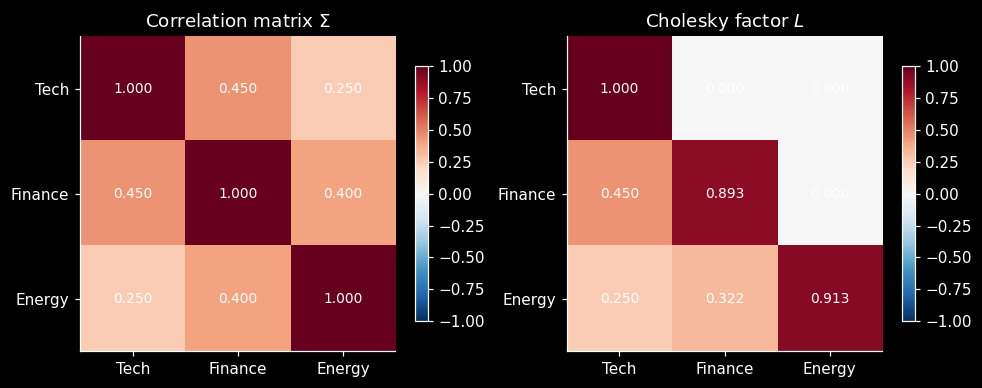

In [4]:
labels = ["Tech", "Finance", "Energy"]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

for ax, mat, title in zip(
    axes, [corr, L], ["Correlation matrix $\\Sigma$", "Cholesky factor $L$"]
):
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(3))
    ax.set_xticklabels(labels)
    ax.set_yticks(range(3))
    ax.set_yticklabels(labels)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center", fontsize=9)
    ax.set_title(title)
    ax.grid(False)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

## 3. Running a simulation

`run()` is the simplest entry point. It wraps `MonteCarloCPU` internally, runs `n_paths` GBM paths, and returns:
- `losses` — a NumPy array of shape `(n_paths,)` where `loss = V0 - V_T`
- `var` — Value at Risk at the requested confidence level
- `es` — Expected Shortfall

A positive loss means the portfolio lost money; a negative loss means it gained.

In [5]:
N_PATHS = 50_000
SEED = 42

t0 = time.perf_counter()
result = run(
    portfolio=portfolio,
    market_model=market_model,
    corr_matrix=corr,
    n_paths=N_PATHS,
    confidence=0.95,
    seed=SEED,
)
elapsed = time.perf_counter() - t0

losses = result["losses"]

print(f"Simulated {len(losses):,} paths in {elapsed:.3f} s")
print(f"\nMean loss  : {losses.mean():+.4f}  (negative = average gain)")
print(f"Std dev    : {losses.std():.4f}")
print(f"Min / Max  : {losses.min():+.4f} / {losses.max():+.4f}")
print(f"\nVaR 95%    : {result['var']:.4f}")
print(f"ES  95%    : {result['es']:.4f}")

Simulated 50,000 paths in 0.758 s

Mean loss  : -12.4114  (negative = average gain)
Std dev    : 27.4619
Min / Max  : -169.3257 / +60.0460

VaR 95%    : 26.4237
ES  95%    : 33.1961


## 4. Loss distribution

The histogram below shows the full distribution of portfolio losses across all simulated paths. VaR and ES mark the right tail.

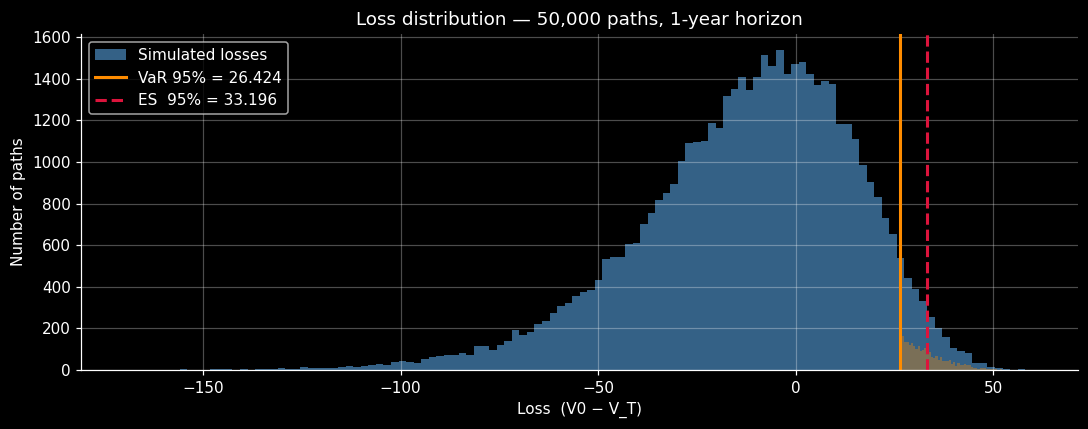

Tail (losses > VaR): 5.0% of paths  (2,500 paths)


In [6]:
var_95 = result["var"]
es_95 = result["es"]

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(losses, bins=120, color="steelblue", alpha=0.75, label="Simulated losses")
ax.axvline(var_95, color="darkorange", lw=2, label=f"VaR 95% = {var_95:.3f}")
ax.axvline(es_95, color="crimson", lw=2, ls="--", label=f"ES  95% = {es_95:.3f}")

# shade the tail beyond VaR
tail_heights, tail_edges = np.histogram(losses[losses >= var_95], bins=60)
ax.bar(
    tail_edges[:-1],
    tail_heights,
    width=np.diff(tail_edges),
    align="edge",
    color="darkorange",
    alpha=0.35,
)

ax.set_xlabel("Loss  (V0 − V_T)")
ax.set_ylabel("Number of paths")
ax.set_title(f"Loss distribution — {N_PATHS:,} paths, 1-year horizon")
ax.legend()
plt.tight_layout()
plt.show()

tail_pct = 100 * float(np.mean(losses > var_95))
print(
    f"Tail (losses > VaR): {tail_pct:.1f}% of paths  ({int(tail_pct * N_PATHS / 100):,} paths)"
)

## 5. Risk metrics at multiple confidence levels

**VaR(α)** — the α-quantile of the loss distribution.  
"With probability α we will not lose more than VaR."

**ES(α)** (also called CVaR or Tail Loss) — the mean of losses that exceed VaR(α).  
"Given that we are in the worst (1−α) fraction of outcomes, the average loss is ES."

ES is a more conservative and mathematically coherent risk measure than VaR — it tells us not just where the tail starts, but how bad it is on average.

In [7]:
print(f"{'Confidence':>12}  {'VaR':>10}  {'ES':>10}  {'Tail paths':>12}")
print("-" * 50)
for conf in (0.90, 0.95, 0.99):
    v = compute_var(losses, conf)
    e = compute_es(losses, conf)
    tail_pct = 100.0 * float(np.mean(losses > v))
    print(f"{conf * 100:>10.0f}%  {v:>10.4f}  {e:>10.4f}  {tail_pct:>10.1f}%")

  Confidence         VaR          ES    Tail paths
--------------------------------------------------
        90%     19.7549     27.9972        10.0%
        95%     26.4237     33.1961         5.0%
        99%     37.6344     42.3090         1.0%


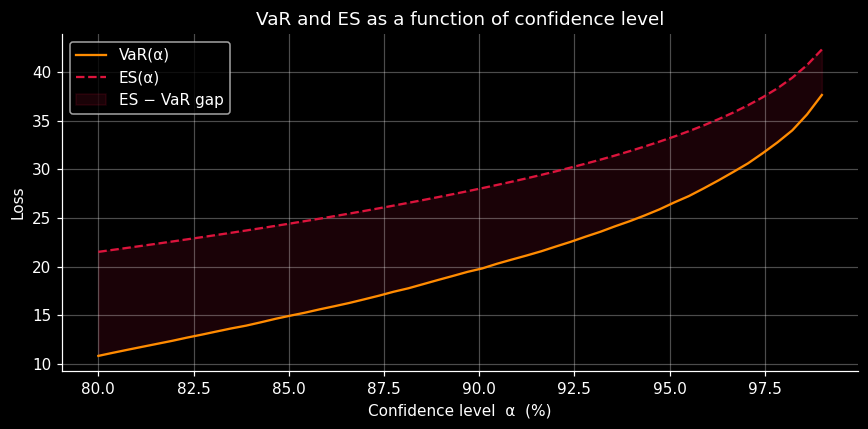

In [8]:
# visualise how VaR and ES shift with the confidence level
confs = np.linspace(0.80, 0.99, 50)
vars_ = [compute_var(losses, c) for c in confs]
ess_ = [compute_es(losses, c) for c in confs]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(confs * 100, vars_, label="VaR(α)", color="darkorange")
ax.plot(confs * 100, ess_, label="ES(α)", color="crimson", ls="--")
ax.fill_between(
    confs * 100, vars_, ess_, alpha=0.12, color="crimson", label="ES − VaR gap"
)
ax.set_xlabel("Confidence level  α  (%)")
ax.set_ylabel("Loss")
ax.set_title("VaR and ES as a function of confidence level")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Comparing allocation strategies

One of the main use-cases of the engine is comparing how weight allocations affect tail risk. We reuse the same `MarketModel` and correlation matrix — only the `Portfolio` weights change.

In [9]:
engine = MonteCarloCPU()

strategies = {
    "Concentrated (80/10/10)": Portfolio(
        S0=portfolio.S0, weights=np.array([0.80, 0.10, 0.10])
    ),
    "Diversified (50/30/20)": portfolio,
    "Equal-weight (33/33/33)": Portfolio(S0=portfolio.S0, weights=np.full(3, 1.0 / 3)),
}

rows = {}
print(f"{'Strategy':<28}  {'V0':>7}  {'VaR 95%':>9}  {'ES 95%':>9}  {'Std dev':>9}")
print("-" * 68)
for name, p in strategies.items():
    ls = engine.run(p, market_model, corr, N_PATHS, seed=SEED)
    v = compute_var(ls, 0.95)
    e = compute_es(ls, 0.95)
    s = ls.std()
    rows[name] = (v, e, s)
    print(f"{name:<28}  {p.initial_value:>7.2f}  {v:>9.4f}  {e:>9.4f}  {s:>9.4f}")

Strategy                           V0    VaR 95%     ES 95%    Std dev
--------------------------------------------------------------------
Concentrated (80/10/10)        134.00    38.6051    47.8152    39.6563
Diversified (50/30/20)         111.00    26.4237    33.1961    27.4619
Equal-weight (33/33/33)         96.67    20.0274    25.5618    20.9590


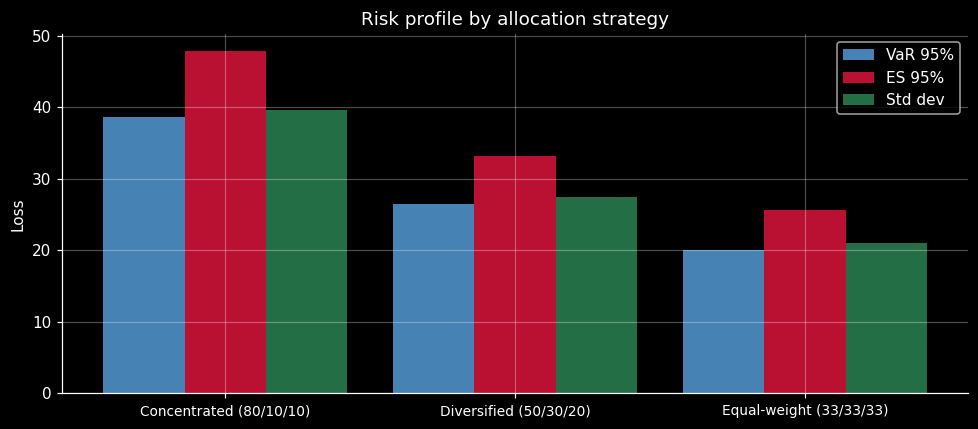

In [10]:
names = list(rows.keys())
vars_s = [rows[n][0] for n in names]
ess_s = [rows[n][1] for n in names]
stds = [rows[n][2] for n in names]

x = np.arange(len(names))
w = 0.28

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w, vars_s, w, label="VaR 95%", color="steelblue")
ax.bar(x, ess_s, w, label="ES 95%", color="crimson", alpha=0.85)
ax.bar(x + w, stds, w, label="Std dev", color="seagreen", alpha=0.80)
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel("Loss")
ax.set_title("Risk profile by allocation strategy")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Stress testing

During a market crisis, asset correlations tend to spike — everything falls together. We re-run the simulation with a stressed correlation matrix to quantify the additional tail risk. This kind of analysis is part of regulatory stress-testing requirements (e.g. Basel III / FRTB).

In [11]:
# crisis scenario: all equity pairs near 0.85–0.90
corr_stress = np.array(
    [
        [1.00, 0.90, 0.85],
        [0.90, 1.00, 0.88],
        [0.85, 0.88, 1.00],
    ]
)

result_base = run(portfolio, market_model, corr, N_PATHS, seed=SEED)
result_stress = run(portfolio, market_model, corr_stress, N_PATHS, seed=SEED)

print(f"{'Scenario':<25}  {'VaR 95%':>9}  {'ES 95%':>9}  {'Std dev':>9}")
print("-" * 58)
print(
    f"{'Base (normal corr)':<25}  "
    f"{result_base['var']:>9.4f}  "
    f"{result_base['es']:>9.4f}  "
    f"{result_base['losses'].std():>9.4f}"
)
print(
    f"{'Stress (crisis corr)':<25}  "
    f"{result_stress['var']:>9.4f}  "
    f"{result_stress['es']:>9.4f}  "
    f"{result_stress['losses'].std():>9.4f}"
)

delta_var = 100 * (result_stress["var"] - result_base["var"]) / abs(result_base["var"])
delta_es = 100 * (result_stress["es"] - result_base["es"]) / abs(result_base["es"])
print(f"\nVaR increase under stress: {delta_var:+.1f}%")
print(f"ES  increase under stress: {delta_es:+.1f}%")

Scenario                     VaR 95%     ES 95%    Std dev
----------------------------------------------------------
Base (normal corr)           26.4237    33.1961    27.4619
Stress (crisis corr)         30.9544    38.4915    30.8921

VaR increase under stress: +17.1%
ES  increase under stress: +16.0%


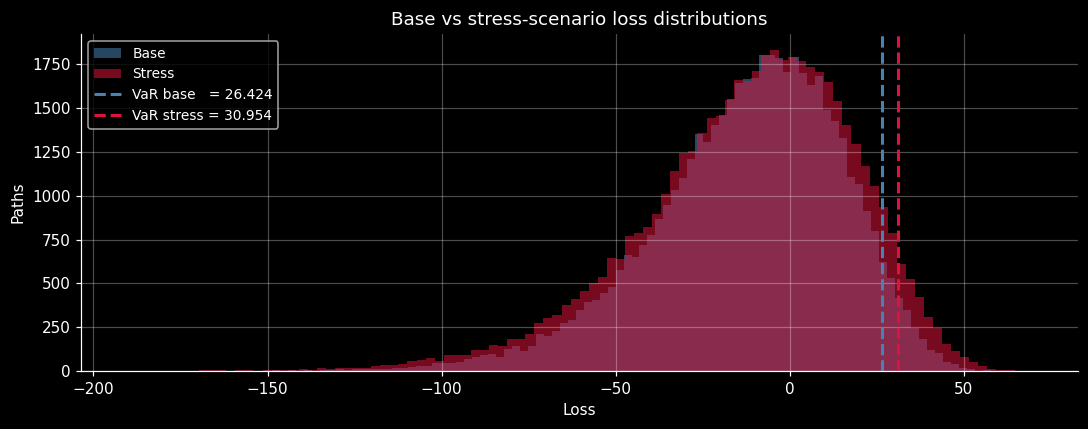

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(result_base["losses"], bins=100, alpha=0.55, color="steelblue", label="Base")
ax.hist(result_stress["losses"], bins=100, alpha=0.55, color="crimson", label="Stress")

ax.axvline(
    result_base["var"],
    color="steelblue",
    lw=2,
    ls="--",
    label=f"VaR base   = {result_base['var']:.3f}",
)
ax.axvline(
    result_stress["var"],
    color="crimson",
    lw=2,
    ls="--",
    label=f"VaR stress = {result_stress['var']:.3f}",
)

ax.set_xlabel("Loss")
ax.set_ylabel("Paths")
ax.set_title("Base vs stress-scenario loss distributions")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. GPU acceleration

`MonteCarloGPU` is a drop-in replacement for `MonteCarloCPU` — it exposes the same `.run()` interface. Under the hood it launches a Numba CUDA kernel where each thread handles one full simulation path.

**Requirements**: Numba + an NVIDIA GPU with CUDA. The first call triggers JIT compilation (~2–5 s); subsequent calls run at full speed.

Since both engines use the same seed, risk metrics should be close (small differences come from their different RNG implementations: NumPy PCG64 vs xoroshiro128p on the GPU).

In [13]:
print(f"Numba available : {_NUMBA_AVAILABLE}")
print(f"CUDA GPU found  : {_CUDA_IS_AVAILABLE}")

Numba available : True
CUDA GPU found  : True


In [14]:
if not _NUMBA_AVAILABLE:
    print("Numba not installed.")
    print("Run: pip install 'portfolio-risk-engine[gpu]'")

elif not _CUDA_IS_AVAILABLE:
    print("Numba installed but no CUDA GPU detected.")
    print('Verify with: python -c "from numba import cuda; print(cuda.gpus)"')

else:
    print("Warming up JIT compiler (~2–5 s on first run) ...")
    gpu_engine = MonteCarloGPU()
    gpu_engine.run(portfolio, market_model, corr, n_paths=1_000, seed=SEED)
    print("Done. Running benchmark (100 000 paths) ...\n")

    bench = compare(
        portfolio,
        market_model,
        corr,
        n_paths=100_000,
        confidence=0.95,
        seed=SEED,
        warmup=False,  # kernel already compiled above
    )

    print(f"{'':5} {'CPU':>12}  {'GPU':>12}")
    print("-" * 32)
    print(f"{'VaR 95%':<12} {bench['cpu_var']:>12.4f}  {bench['gpu_var']:>12.4f}")
    print(f"{'ES  95%':<12} {bench['cpu_es']:>12.4f}  {bench['gpu_es']:>12.4f}")
    print(
        f"{'Time (s)':<12} {bench['cpu_time_s']:>12.4f}  {bench['gpu_time_s']:>12.4f}"
    )
    print(f"{'Speedup':<12} {'—':>12}  {bench['speedup']:>11.1f}x")

Warming up JIT compiler (~2–5 s on first run) ...


C:\Users\BadiiiX\.conda\envs\montecarlo-portfolio-risk-gpu\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Done. Running benchmark (100 000 paths) ...

               CPU           GPU
--------------------------------
VaR 95%           26.4753       26.2983
ES  95%           33.2165       33.1548
Time (s)           1.4714        0.0311
Speedup                 —         47.2x


## Summary

The engine follows a simple layered structure:

```
domain/
    Portfolio, MarketModel          — data containers
    compute_cholesky()              — correlation decomposition
    compute_var(), compute_es()     — risk metrics from a losses array

infrastructure/simulation/
    SimulationEngine (ABC)          — common interface
    MonteCarloCPU                   — NumPy vectorised GBM
    MonteCarloGPU                   — Numba CUDA, one thread per path

application/
    run()                           — one-liner CPU simulation
    compare()                       — CPU vs GPU timing
```

Switching from CPU to GPU is a single line:

```python
engine = MonteCarloCPU()   # numpy
engine = MonteCarloGPU()   # cuda — identical interface
losses = engine.run(portfolio, market_model, corr, n_paths=1_000_000, seed=42)
```